# Coupled ABM: FloodAdapt × DYNAMO-M

## 1. Introduction and context

### 1.1 Context and aim of the coupling project

The FloodAdapt-ABM coupling project integrates the physical flood risk modelling of FloodAdapt (using SFINCS and FIAT) with the behavioural agent-based modelling of DYNAMO-M. The goal is to provide a comprehensive framework to assess how household-level adaptation decisions (like floodproofing) evolve dynamically alongside rising sea levels and stochastic flood events over time.

### 1.2 Aim of this notebook

This notebook serves as the runner for simulating adaptation. It demonstrates how to initialize the simulation engine, configure the Subjective Expected Utility (SEU) decision rules, run the simulation, and visualize the adaptation outcomes over a multi-decade horizon.

### 1.3 What falls under minimum viable product (MVP)

The MVP for this coupling bridges the core SEU decision kernel from DYNAMO-M. It evaluates how agents perceive risk based on recent flood events, calculates their expected utility for taking action, and applies affordability constraints. The coupling additionally supports **flood insurance** as a third decision option (`include_insurance=True`, off by default, matching native DYNAMO-M), a statistically exact **Poisson hazard draw**, **severity-scaled risk perception** (three selectable response forms), a **synthetic income model** ported from native DYNAMO-M, and an explicit **household income workflow** (Section 2.6). It specifically excludes broader DYNAMO-M features such as the gravity models (for migration), regional economic feedbacks, and the government dike-CBA agent. These are reserved for future phases; a feasibility assessment for the government extension is kept with the project deliverables outside this repository.

### 1.4 Why a lightweight `AgentState` instead of full DYNAMO-M

Instead of spinning up the massive DYNAMO-M ecosystem (which involves parsing gigabytes of geospatial data and instantiating memory-heavy `CoastalNode` instances for every building), this engine uses a lightweight `AgentState` array structure. This allows us to load only the exact property values, damage estimates, and event probabilities needed for the SEU logic from the NetCDF lookup table. This ensures the simulation runs rapidly (in seconds instead of hours) while remaining mathematically bit-for-bit identical to the native DYNAMO-M execution.

### 1.5 One engine, clearly-labelled roles

This repository has exactly **one** compute kernel, `SimulationEngine.step`, and several *drivers* that own the clock around it. Their roles:

| Entry point | Role | Use it for |
|---|---|---|
| `run_mesa_native_full` | **MAIN engine**: the real honeybees `Model` (native DYNAMO-M framework) owns the clock | All application runs (this notebook) |
| `engine.run(n_jobs=...)` | Compute kernel + parallel Monte-Carlo backend | Verification & experiments |
| `run_mesa_native` | Framework-free mirror of the native tick loop | The Phase-4b bit-parity gate (verification) |
| `ABMSimulator` | Deprecated legacy threshold simulator | Backward compatibility only |

The intermediate drivers exist because the coupling was built as a **step-wise verification ladder** (kernel, then framework-free mirror, then native honeybees integration), each step gated by bit-for-bit parity so the coupled version provably never drifted from the validated science. They are retained as verification gates, not as alternative models.

### 1.6 Documentation guide: what to read next?

The repository keeps two core documents with distinct roles, plus one method guide:

1. **`docs/architecture.md`**, the **design record**: *why and how the system is built*. Coupling architecture, the SEU decision science for adaptation and insurance, severity-response formulations, deviations from native DYNAMO-M (Appendix B).
2. **`floodadapt_abm_documentation.md`**, the **reference manual**: *how to use the package*. Every module, class, function and configuration field, with examples.
3. **`docs/calibration_validation_guide.md`**, the **method guide**: how to calibrate and validate the behavioural parameters.

`README.md` (root) is the front door: quick-start, installation, pipeline overview.

## 2. Workflow setup

This section covers the common initialization steps required before running the simulation: environment setup, helper functions, the core architecture, Monte-Carlo sequences for uncertainty, and the scenario configuration.

### 2.1 Setup

We start by importing the necessary packages and loading a pre-computed lookup table generated by Stage 1 (`setup_lookup_table.py`). 
This NetCDF file (`.nc`) contains matrices for inundation depth and economic damage per building, sea-level-rise (SLR) scenario, strategy, and event. This pre-computation removes the need to run heavy physical models (SFINCS or FIAT) during the agent simulation, making it exceptionally fast.

In [1]:
import sys, os, platform
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# Make floodadapt_abm importable and reuse the examples' dataset loader.
_REPO = Path.cwd()
if _REPO.name == "notebooks":
    _REPO = _REPO.parent
sys.path.insert(0, str(_REPO))
sys.path.insert(0, str(_REPO / "examples_engine"))

from _shared import load_dataset  # noqa: E402

import floodadapt_abm as fabm
from floodadapt_abm import (
    SimulationEngine, CouplingConfig, DecisionConfig,
    SEURule, ThresholdRule, DynamoLiveRule,
    preferred_decision_rule,
    run_mesa_native, run_mesa_native_full,
    DYNAMO_M_AVAILABLE, HONEYBEES_AVAILABLE,
)

print("Python           :", platform.python_version())
print("numpy / xarray   :", np.__version__, "/", xr.__version__)
print("honeybees present:", HONEYBEES_AVAILABLE, " (real Mesa/honeybees run path)")
print("DYNAMO-M present :", DYNAMO_M_AVAILABLE, " (native DecisionModule parity)")

Python           : 3.11.14
numpy / xarray   : 1.26.4 / 2025.11.0
honeybees present: True  (real Mesa/honeybees run path)
DYNAMO-M present : True  (native DecisionModule parity)


### 2.2 Helper functions (for plotting, data processing, etc.)

We define several utility functions here to process the simulation output, generate statistical summaries using `pandas`, and plot the results using `matplotlib`. These functions help keep the main execution blocks clean and readable.

In [2]:
def create_summary_table(n_adapted, adoption, damage, base_damage, no_seq):
    import pandas as pd
    import numpy as np
    
    dmg_year = damage.sum(axis=1) / 1e6
    avoided_year = np.clip(base_damage - damage, 0, None).sum(axis=1) / 1e6
    
    summary = pd.DataFrame({
        "sequence":            [f"seq {s}" for s in range(no_seq)],
        "final adopted (#)":   n_adapted[:, -1],
        "final adopted (%)":   (adoption[:, -1] * 100).round(1),
        "cum. damage (M$)":    dmg_year.sum(axis=1).round(1),
        "cum. avoided (M$)":   avoided_year.sum(axis=1).round(1),
    })
    agg = pd.DataFrame({
        "sequence": ["MEAN", "STD"],
        "final adopted (#)":   [n_adapted[:, -1].mean().round(1),  n_adapted[:, -1].std().round(1)],
        "final adopted (%)":   [(adoption[:, -1]*100).mean().round(1), (adoption[:, -1]*100).std().round(1)],
        "cum. damage (M$)":    [dmg_year.sum(axis=1).mean().round(1),  dmg_year.sum(axis=1).std().round(1)],
        "cum. avoided (M$)":   [avoided_year.sum(axis=1).mean().round(1), avoided_year.sum(axis=1).std().round(1)],
    })
    return pd.concat([summary, agg], ignore_index=True), dmg_year, avoided_year

def plot_results(years, slr_values, n_adapted, dmg_year, avoided_year, no_seq):
    import matplotlib.pyplot as plt
    import numpy as np
    
    cum_avoided_year = np.cumsum(avoided_year, axis=1)
    fig, axes = plt.subplots(1, 4, figsize=(23, 4.6))
    slr_color = "#6c757d"

    def overlay_slr(ax):
        axr = ax.twinx()
        axr.plot(years, slr_values, color=slr_color, ls="--", lw=1.8, label="SLR trajectory")
        axr.set_ylabel("Sea-level rise (table units)", color=slr_color)
        axr.tick_params(axis="y", labelcolor=slr_color)
        axr.set_ylim(bottom=min(0, float(slr_values.min())))
        return axr

    metrics = [
        (n_adapted, "(a) Households adapted per year", "# households floodproofed", "C0"),
        (dmg_year, "(b) Total flood damage per year", "Damage (M$)", "C1"),
        (avoided_year, "(c) Avoided damage per year (vs never-adapt)", "Avoided damage (M$)", "C2"),
        (cum_avoided_year, "(d) Cumulative avoided damage (vs never-adapt)", "Cumulative avoided damage (M$)", "C3"),
    ]
    
    for i, (data, title, ylabel, color) in enumerate(metrics):
        ax = axes[i]
        for s in range(no_seq):
            ax.plot(years, data[s], color=color, alpha=0.30, lw=1, label="individual sequence" if s == 0 else "")
        m, sd = data.mean(0), data.std(0)
        ax.plot(years, m, color=color, lw=2.4, label="mean (across sequences)")
        ax.fill_between(years, np.maximum(0, m - sd), m + sd, color=color, alpha=0.20, label="±1 s.d. uncertainty")
        ax.set_title(title)
        ax.set_xlabel("Year"); ax.set_ylabel(ylabel)
        axr = overlay_slr(ax)
        lines_ax, labels_ax = ax.get_legend_handles_labels()
        lines_axr, labels_axr = axr.get_legend_handles_labels()
        ax.legend(lines_ax + lines_axr, labels_ax + labels_axr, loc="upper left")

    fig.suptitle(f"Coupled ABM outcomes under rising SLR - {no_seq} sequences, mean ±1 s.d.", y=1.03)
    fig.tight_layout()
    plt.show()


### 2.3 The coupled architecture, concisely

The simulation is built around three main components:
1. **Kernel**: The core computational function (`SimulationEngine.step`) that performs the numeric work every simulated year.
2. **Decision Rule**: A pluggable logic module that governs household behaviour (e.g., whether to adopt floodproofing).
3. **Clock Owner**: The outer loop that advances time.

Because the different execution methods (paths) share the exact same kernel and the same sequence of random numbers (Random Number Generator stream), they produce bit-for-bit identical results. This ensures reproducibility whether you run the full native model or the lightweight mirror.

| Piece | Responsibility | Provided by |
|---|---|---|
| **Lookup table** | Flood damage per building / SLR / event / strategy | **FloodAdapt** |
| **`LookupTableAdapter`** | Maps table data to agent arrays; interpolates at each SLR | This repo |
| **`SimulationEngine.step`** | The single per-year kernel (events, damage, state updates) | This repo |
| **Decision rule** | Logic to adapt or not each year (SEU / native / threshold) | DYNAMO-M science, pluggable |
| **Clock owner** | Advances the year loop | Execution methods |

### 2.4 Monte-Carlo sequences and multiprocessing

**Sequences.** Flood events are *stochastic* (random): each year, each event either happens or not based on its probability. A single run represents just one possible "weather history". To capture uncertainty, we run **several independent sequences** with different random streams and report the **mean ± spread** (standard deviation).

**Multiprocessing.** Because sequences are independent, they can be run in parallel. `engine.run(..., n_jobs=N)` distributes the sequences across multiple processor cores. The parallel result is **bit-identical** to the sequential one. It just finishes much faster.

### 2.5 Configuration

The `DecisionConfig` defaults are:

- **Poisson hazard draw** (`event_draw_mode="poisson"`, no discard cap). Event frequencies are occurrence *rates*, so every event's realised long-run rate matches its nominal frequency. Rare extremes are never crowded out by frequent nuisance events. In plain terms: the Poisson distribution answers "how many times does something with a known average rate happen this year", so nothing needs to be clipped or thrown away.
- **Exceedance SEU probabilities** (`seu_prob_mode="exceedance"`, `p = 1 − e^(−freq)`).
- **Severity-scaled risk perception** (`perception_mode="severity"`). A nuisance flood and a catastrophe no longer look identical to the agent. The response shape is selectable via `perception_severity_form` (concave power law by default; see `docs/architecture.md` and the calibration guide for the alternatives and how to choose).
- **Synthetic lognormal incomes** (`income_mode="synthetic_lognormal"`, native DYNAMO-M port). Income is independent of building value, so the affordability constraint genuinely binds. Section 2.6 shows how the percentiles are assigned for this case study.

For the **real Charleston table** we additionally set `nuisance_freq_threshold = 1.0`. Its probabilistic event set contains ~11 sub-annual (`freq > 1`) events whose near-certain probabilities would otherwise collapse onto the 0.998 perceived-probability cap inside the SEU integral. This also reproduces the pre-coupling convention of disregarding sub-annual events.

In [3]:
# --- Scenario ---------------------------------------------------------------
START_YEAR = 2020
N_YEARS    = 30
NO_SEQ     = 5          # Monte-Carlo sequences
SEED       = 42

# --- Dataset Selection: Synthetic vs. Real Charleston Table ----------------
# OPTION 1: Run on the fast SYNTHETIC table (runs in seconds)
# USE_REAL_TABLE = False

# OPTION 2: Run on the real 2GB CHARLESTON table (takes several minutes)
USE_REAL_TABLE = True

# OPTION 3: Control via environment variable (useful for CI/automated runs)
# USE_REAL_TABLE = os.environ.get("FA_ABM_REAL_TABLE", "0").lower() in ("1", "true", "yes")

ds, source = load_dataset(prefer_real=USE_REAL_TABLE)
print(f"Lookup table : {source}")
print(f"dimensions   : {dict(ds.sizes)}")

# --- Decision / coupling configuration --------------------------------------
# Current defaults: Poisson hazard draw, exceedance SEU probabilities,
# severity-scaled perception, synthetic lognormal incomes.
# (CouplingConfig.legacy() reproduces the historical behaviour bit-exactly.)
config = CouplingConfig(random_seed=SEED)
if "real" in source:
    # Recommended for the Charleston probabilistic set: drop sub-annual
    # nuisance events (freq > 1/yr) from the catalogue (see Section 2.5).
    config.decision.nuisance_freq_threshold = 1.0

# Household income percentiles are assigned in Section 2.6 below.

# --- SLR trajectory (the driver) --------------------------------------------
# Preferred, if a FloodAdapt database is available:
#   import flood_adapt.api as fa
#   slr_values = np.array([fa.interp_slr(slr_scenario="NOAA High", year=START_YEAR+t)
#                          for t in range(N_YEARS)])

# Fallback: a linear ramp across the lookup table's SLR grid.
slr_values = np.linspace(float(ds.slr.min()), float(ds.slr.max()), N_YEARS)
years = START_YEAR + np.arange(N_YEARS)
print(f"SLR trajectory: {slr_values[0]:.2f} -> {slr_values[-1]:.2f} "
      f"({ds.slr.attrs.get('units', 'table units')}) over {N_YEARS} years")

Lookup table : real Charleston table (lookup_table_charleston_beta_release_ABM_probabilistic_set.nc)
dimensions   : {'object_id': 61858, 'slr': 5, 'strategy': 2, 'event': 207}
SLR trajectory: 0.00 -> 2.00 (table units) over 30 years


### 2.6 Assigning household incomes

The engine reads each household's income off a regional income distribution at that household's **income percentile**. A percentile of 80 means the household earns more than 80 % of households in the region. This mirrors native DYNAMO-M.

**Two separate inputs, and they need different data.** Keeping them apart is what makes this workable without building locations:

| Axis | What it fixes | Set by | Needs building locations? |
|---|---|---|---|
| 1. The **marginal distribution** | how much a household at percentile *p* earns | `median_income`, `mean_median_inc_ratio` | **No.** It is a property of the whole study area |
| 2. The **rank assignment** | which *building* sits at percentile *p* | `income_percentile_per_agent` | **Yes**, unless you assume a proxy |

Axis 1 is measurable from published county totals for any US county, with no geometry at all. Axis 2 is the one that needs footprints. The tiers below grade axis 2 only. Calibrating axis 1 is worth doing at every tier, including the fallback, and this notebook does it.

#### Axis 2: the three tiers, best data first

**Tier A: real income data joined by location (best).**
Use ACS block-group median household income plus the building footprints. Jargon, defined: **ACS** is the US Census Bureau's American Community Survey. **B19013** is its table "Median Household Income in the Past 12 Months". A **block group** is the smallest census area with published income data (about 600 to 3,000 people). **5-year** means pooled over five survey years, which makes small-area figures reliable. Steps:

1. Get the **income values**. Table B19013 comes from the Census Data API, one row per block group. A free API key is needed (sign up at `api.census.gov/data/key_signup.html`; requests without one are rejected). For Charleston County the geography is `state:45 county:019`.
2. Get the **income geometries**. Block-group polygons come from TIGER/Line shapefiles, which need no key. Join them to the values on `GEOID`, the 12-digit block-group identifier. The result is the polygon layer the helper calls **`regions_gdf`**: one row per block group, with a `median_hh_income` column and a `geometry` column.
3. Get the **building footprints. This is the hard requirement, and the step that blocks Tier A here.** The lookup `.nc` deliberately carries no coordinates: its `object_id` axis holds only `max_pot_dmg` and `primary_object_type`. Nothing in the table says where a building is. The geometry has to come from the **FloodAdapt database** that built the table, via `fa.get_building_footprint_impacts(scenario)`, which returns a GeoDataFrame keyed by Object ID. That needs the `[pipeline]` extra and the database itself. Without it there is no way to link a block group to an agent, so steps 1 and 2 alone cannot produce percentiles. Reindex the result to this table's residential agent order, so row *i* is agent *i*.
4. **Join and convert.** `income_utils.derive_income_percentiles(buildings, regions_gdf, income_column="median_hh_income")` does the spatial join and turns each building's block-group income into a percentile (needs geopandas). Buildings in richer block groups land on higher percentiles; a small jitter keeps households within one block group from being identical.
5. Save as `income_percentiles_charleston.npy` next to this notebook. The cell below picks the file up automatically.

The next cell defines `fetch_acs_block_group_income` and `fetch_tract_income`, which perform steps 1 and 2 and return `regions_gdf`. They are defined but not called, because step 3 is unavailable on this machine: there is no FloodAdapt database here. They do work: run against the live API they return 261 Charleston County block groups, 237 of them with a published income.

**Tier B: coarser open proxies.** If block-group income is unavailable, drop one level to census tracts (`fetch_tract_income` in the next cell, 99 tracts for Charleston County). Outside the US, any polygon layer with an income or GDP-per-capita column works as `regions_gdf`: Global Data Lab subnational areas (`globaldatalab.org`) publish income and HDI per region, and a WorldPop wealth or population grid can be dissolved to admin units. Nothing else in the workflow changes, **including the footprint requirement**: Tier B still needs building locations to join against. Coarser regions carry less contrast between households, so keep the jitter on.

**Tier C: no locations at all (what runs here).** This machine has neither the footprints nor a FloodAdapt database, so a spatial join is impossible. The only per-household covariate in the table is the building value (`max_pot_dmg`). Household income and housing value are correlated, but far from perfectly: rank correlations of roughly 0.4 to 0.6 in household-finance data. Tier C encodes exactly that with `income_utils.percentiles_from_value_proxy`: the income percentile follows the building-value rank with a target rank correlation of 0.5, plus noise. **This is an assumption, not data.** It restores plausible sorting of income against risk without repeating the old degenerate identity (income exactly proportional to building value). Treat the 0.5 as a calibration target with bounds 0.3 to 0.7 (see `docs/calibration_validation_guide.md`). Passing `None` instead gives the zero-assumption uniform fallback (the native default).

#### Axis 1: calibrating the marginal, and checking it

Losing the footprints costs us axis 2. It costs us nothing on axis 1, so there is no excuse for leaving the regional distribution at a generic default. The next-but-one cell sets it from real Charleston County figures: median household income from ACS table B19013, and the mean from aggregate household income (B19025) divided by households (B11001), because ACS publishes no mean directly. The model needs exactly that pair, since it fits `mu = ln(median)` and `sd = sqrt(2 ln(mean/median))`.

**Source:** US Census Bureau, American Community Survey, 2019-2023 5-year estimates, Charleston County SC (state FIPS 45, county FIPS 019). Fetched with `fetch_acs_county_income("45", "019")` and pinned in the cell below so the notebook reproduces offline. Verify by hand with no key needed: [B19013 median](https://data.census.gov/table/ACSDT5Y2023.B19013?g=050XX00US45019), [B19025 aggregate](https://data.census.gov/table/ACSDT5Y2023.B19025?g=050XX00US45019), [B11001 households](https://data.census.gov/table/ACSDT5Y2023.B11001?g=050XX00US45019), or the [county profile page](https://data.census.gov/profile/Charleston_County,_South_Carolina?g=050XX00US45019). The machine-readable API call is quoted in the cell below.

Two numbers fit a lognormal, but they do not prove the *shape* is right. So the cell also validates it against ACS table **B19001**, which counts households in 16 income brackets, and reports the total-variation distance: the fraction of households the model puts in the wrong bracket. The package defaults ($70,000, ratio 1.15) misplace about 31 % of Charleston households, mostly by inventing a thin upper tail where the real county has a fat one. The calibrated pair misplaces about 7 %. The remaining gap sits in the lowest brackets, where a lognormal cannot reproduce the spike of near-zero-income households; that is a known limit of the functional form, not a fitting error, and it is recorded rather than tuned away.

The measured values are **pinned as constants** so this notebook reproduces offline and the figures stay stable. When `CENSUS_API_KEY` is set, the cell re-fetches them and reports any drift against the pinned values instead of silently using different numbers.

One practical note: supplying percentiles changes what the income random stream draws, so downstream numbers shift relative to an older uniform-fallback run at the same seed. That is expected, not a regression.

In [4]:
# --- Tier A / Tier B: income data joined by location (runs when available) ---
# This cell only LOADS a percentile file if a previous run produced one.
# The two helpers below show how to actually build one. They are defined but
# not called: both need network access, a Census API key and geopandas.
#
# The key is free. Request one at https://api.census.gov/data/key_signup.html
# (organisation name + email, arrives by email in a few minutes). It is read
# from the CENSUS_API_KEY environment variable so it never appears in this
# notebook or in git. Set it once per machine:
#     PowerShell:  setx CENSUS_API_KEY "your-key-here"   (then open a new shell)
#     bash:        export CENSUS_API_KEY=your-key-here
#
# TIGER/Line shapefiles are large (about 16 MB per state layer), so they are
# cached outside the repository. Override the location with FA_ABM_CENSUS_CACHE.
import os
import tempfile

CENSUS_CACHE = Path(
    os.environ.get(
        "FA_ABM_CENSUS_CACHE",
        Path(tempfile.gettempdir()) / "floodadapt_abm_census",
    )
)


def _census_api_key(api_key=None):
    """Resolve the Census API key from the argument or the environment.

    Raises a directed error rather than letting an unauthenticated request
    fail later with a confusing parse error.
    """
    key = api_key or os.environ.get("CENSUS_API_KEY")
    if not key:
        raise RuntimeError(
            "No Census API key found. Request a free one at "
            "https://api.census.gov/data/key_signup.html, then set the "
            "CENSUS_API_KEY environment variable "
            '(PowerShell: setx CENSUS_API_KEY "your-key-here").'
        )
    return key


def _census_get_json(url):
    """GET a Census Data API URL and return the parsed JSON payload.

    The API answers a missing or invalid key with HTTP 200 and an HTML
    "Missing Key" page, so a plain json.load raises a misleading
    JSONDecodeError pointing at line 1 column 1. Detect that case and say
    what is actually wrong.
    """
    import json as _json
    import urllib.request

    with urllib.request.urlopen(url, timeout=120) as resp:
        content_type = resp.headers.get("Content-Type", "")
        body = resp.read()
    head = body[:200].lstrip().lower()
    if ("html" in content_type.lower()
            or head.startswith(b"<html")
            or head.startswith(b"<!doctype")):
        raise RuntimeError(
            "The Census API returned an HTML page instead of data. This "
            "means the API key is missing or invalid: the API answers with "
            "HTTP 200 and a 'Missing Key' page rather than an error status. "
            "Request a free key at "
            "https://api.census.gov/data/key_signup.html and set "
            "CENSUS_API_KEY."
        )
    return _json.loads(body)


def _download_tiger(url, dest_dir):
    """Download and extract a TIGER/Line shapefile once, then reuse it.

    Returns the directory holding the extracted shapefile, which geopandas
    can read directly.
    """
    import io
    import urllib.request
    import zipfile

    dest_dir = Path(dest_dir)
    if any(dest_dir.glob("*.shp")):          # already downloaded earlier
        return dest_dir
    dest_dir.mkdir(parents=True, exist_ok=True)
    with urllib.request.urlopen(url, timeout=300) as resp:
        buf = io.BytesIO(resp.read())
    zipfile.ZipFile(buf).extractall(dest_dir)
    return dest_dir


def fetch_acs_block_group_income(state_fips, county_fips, api_key=None,
                                 year=2023, cache_dir=None):
    """Download ACS median household income per block group as a GeoDataFrame.

    The return value is the `regions_gdf` that `derive_income_percentiles`
    expects: one polygon per block group, carrying an income column.

    Two public sources are combined:
      1. the values, from the Census Data API (table B19013, 5-year ACS).
         A free key is required, read from CENSUS_API_KEY if not passed.
      2. the geometries, from TIGER/Line shapefiles (no key needed).
    They are joined on GEOID, the code identifying a block group.

    Charleston County, SC is state_fips="45", county_fips="019".
    """
    import geopandas as gpd
    import pandas as pd

    key = _census_api_key(api_key)
    cache = Path(cache_dir) if cache_dir is not None else CENSUS_CACHE

    # 1. values: one row per block group; B19013_001E = median household income
    api = (f"https://api.census.gov/data/{year}/acs/acs5"
           f"?get=NAME,B19013_001E&for=block%20group:*"
           f"&in=state:{state_fips}%20county:{county_fips}&key={key}")
    rows = _census_get_json(api)
    inc = pd.DataFrame(rows[1:], columns=rows[0])
    # GEOID = state(2) + county(3) + tract(6) + block group(1) = 12 digits
    inc["GEOID"] = (inc["state"] + inc["county"]
                    + inc["tract"] + inc["block group"])
    inc["median_hh_income"] = pd.to_numeric(inc["B19013_001E"], errors="coerce")
    # ACS marks suppressed estimates with negative sentinels (e.g. -666666666).
    inc.loc[inc["median_hh_income"] < 0, "median_hh_income"] = float("nan")

    # 2. geometries: statewide block groups, filtered to the county
    tiger = (f"https://www2.census.gov/geo/tiger/TIGER{year}/BG/"
             f"tl_{year}_{state_fips}_bg.zip")
    shp_dir = _download_tiger(tiger, cache / f"tiger_bg_{year}_{state_fips}")
    gdf = gpd.read_file(shp_dir)
    gdf = gdf[gdf["COUNTYFP"] == county_fips]

    # 3. values onto geometries -> this is regions_gdf
    return gdf.merge(inc[["GEOID", "median_hh_income"]], on="GEOID", how="left")


def fetch_tract_income(state_fips, county_fips, api_key=None,
                       year=2023, cache_dir=None):
    """Tier B fallback: the same join one level coarser, at tract level.

    Use when block-group estimates are too noisy or unpublished. A tract holds
    about 1,200 to 8,000 people; a block group about 600 to 3,000.

    Outside the US, replace this with any polygon layer carrying an income or
    GDP-per-capita column: Global Data Lab subnational areas
    (globaldatalab.org), or a WorldPop wealth grid dissolved to admin units.
    Nothing else changes: any GeoDataFrame with an income column is a valid
    regions_gdf.
    """
    import geopandas as gpd
    import pandas as pd

    key = _census_api_key(api_key)
    cache = Path(cache_dir) if cache_dir is not None else CENSUS_CACHE

    api = (f"https://api.census.gov/data/{year}/acs/acs5"
           f"?get=NAME,B19013_001E&for=tract:*"
           f"&in=state:{state_fips}%20county:{county_fips}&key={key}")
    rows = _census_get_json(api)
    inc = pd.DataFrame(rows[1:], columns=rows[0])
    inc["GEOID"] = inc["state"] + inc["county"] + inc["tract"]
    inc["median_hh_income"] = pd.to_numeric(inc["B19013_001E"], errors="coerce")
    inc.loc[inc["median_hh_income"] < 0, "median_hh_income"] = float("nan")

    tiger = (f"https://www2.census.gov/geo/tiger/TIGER{year}/TRACT/"
             f"tl_{year}_{state_fips}_tract.zip")
    shp_dir = _download_tiger(tiger, cache / f"tiger_tract_{year}_{state_fips}")
    gdf = gpd.read_file(shp_dir)
    gdf = gdf[gdf["COUNTYFP"] == county_fips]
    return gdf.merge(inc[["GEOID", "median_hh_income"]], on="GEOID", how="left")


# --- The full Tier A workflow, end to end -----------------------------------
# Run once, with a Census API key and a FloodAdapt database at hand:
#
#   import flood_adapt.api as fa
#   from floodadapt_abm.income_utils import derive_income_percentiles
#
#   # (a) regions_gdf: the income polygons (function above). The key comes
#   #     from CENSUS_API_KEY, so nothing secret is written down here.
#   regions_gdf = fetch_acs_block_group_income("45", "019")
#
#   # (b) buildings: footprints keyed by Object ID, from the FloodAdapt
#   #     database (needs the [pipeline] extra). The lookup .nc carries no
#   #     coordinates, so the geometry has to come from here.
#   buildings = fa.get_building_footprint_impacts(scenario_name)  # GeoDataFrame
#
#   # (c) align buildings to this table's residential agent order
#   types = np.asarray(ds["object_id"].attrs["primary_object_type"], dtype=str)
#   res_mask = np.char.find(types, "RES") >= 0
#   buildings_res = buildings.set_index("Object ID").reindex(
#       np.asarray(ds["object_id"].values)[res_mask])
#
#   # (d) spatial join + percentiles, then cache for later runs
#   pct = derive_income_percentiles(buildings_res, regions_gdf,
#                                   income_column="median_hh_income")
#   np.save("income_percentiles_charleston.npy", pct)
#
# Tier B is identical except for step (a): swap in fetch_tract_income(...),
# or any other polygon layer with an income column.

_pct_file = Path("income_percentiles_charleston.npy")
income_percentiles = np.load(_pct_file) if _pct_file.exists() else None
print("Tier A/B percentile file:",
      f"loaded ({_pct_file})" if income_percentiles is not None else "not found")

Tier A/B percentile file: not found


In [5]:
# --- Tier C: county income statistics + building-value proxy (runs here) -----
from floodadapt_abm.income_utils import (
    ACS_B19001_LABELS,
    bracket_fit_distance,
    fetch_acs_county_income,
    fetch_acs_income_brackets,
    lognormal_bracket_shares,
    percentiles_from_value_proxy,
)

# === Axis 1: the regional income distribution (needs NO building locations) ==
# SOURCE: US Census Bureau, American Community Survey, 2019-2023 5-year
# estimates, Charleston County, South Carolina (state FIPS 45, county FIPS
# 019). Fetched with income_utils.fetch_acs_county_income("45", "019") on
# 2026-08-06 and pinned below so this notebook reproduces offline.
#
# Machine-readable (what fetch_acs_county_income calls), reproduce with:
#   https://api.census.gov/data/2023/acs/acs5?get=NAME,B19013_001E,B19025_001E,B11001_001E&for=county:019&in=state:45&key=YOUR_KEY
# Human-browsable, no key needed, to eyeball the same tables:
#   https://data.census.gov/table/ACSDT5Y2023.B19013?g=050XX00US45019   (median)
#   https://data.census.gov/table/ACSDT5Y2023.B19025?g=050XX00US45019  (aggregate)
#   https://data.census.gov/table/ACSDT5Y2023.B11001?g=050XX00US45019  (households)
#   https://data.census.gov/profile/Charleston_County,_South_Carolina?g=050XX00US45019
#
#   B19013_001E  median household income      $84,320
#   B19025_001E  aggregate household income   $22,267,010,600
#   B11001_001E  households                   175,499
#   mean = aggregate / households              $126,878
#
# Pinned as constants so this notebook reproduces offline and the figures stay
# stable. Set CENSUS_API_KEY to re-fetch and check them against the live API
# (the cell below reports any drift rather than silently using new numbers).
ACS_MEDIAN_HH_INCOME = 84_320.0
ACS_MEAN_HH_INCOME   = 126_878.0

config.decision.median_income = ACS_MEDIAN_HH_INCOME
config.decision.mean_median_inc_ratio = ACS_MEAN_HH_INCOME / ACS_MEDIAN_HH_INCOME

_have_key = bool(os.environ.get("CENSUS_API_KEY"))
if _have_key:
    _live = fetch_acs_county_income("45", "019")
    _drift = abs(_live["mean_income"] - ACS_MEAN_HH_INCOME) / ACS_MEAN_HH_INCOME
    print(f"ACS live check    : median ${_live['median_income']:,.0f}, "
          f"mean ${_live['mean_income']:,.0f} over "
          f"{_live['n_households']:,.0f} households "
          f"(pinned mean differs by {_drift * 100:.4f} %)")
else:
    print("ACS live check    : skipped, no CENSUS_API_KEY set; using pinned values")

print(f"regional income   : median ${config.decision.median_income:,.0f}, "
      f"mean/median {config.decision.mean_median_inc_ratio:.4f} (ACS 2019-2023)")

# --- Validation: does the fitted lognormal match the real histogram? --------
# Two numbers fit the distribution. Only the observed histogram (ACS table
# B19001, 16 income brackets) shows whether the resulting SHAPE is right.
# Total-variation distance reads as the fraction of households placed in the
# wrong bracket: 0 is perfect.
if _have_key:
    _obs = fetch_acs_income_brackets("45", "019")["shares"]
    _fit = lognormal_bracket_shares(config.decision.median_income,
                                    config.decision.mean_median_inc_ratio)
    _gen = lognormal_bracket_shares(70_000.0, 1.15)   # package defaults
    print(f"\nmarginal fit vs ACS B19001 (total-variation distance, 0 = perfect)")
    print(f"  package defaults  $70,000 / 1.150 : "
          f"{bracket_fit_distance(_obs, _gen):.3f}")
    print(f"  ACS-calibrated   ${config.decision.median_income:,.0f} / "
          f"{config.decision.mean_median_inc_ratio:.3f} : "
          f"{bracket_fit_distance(_obs, _fit):.3f}")
    print(f"\n  {'bracket':>9s} {'observed':>9s} {'fitted':>8s} {'default':>9s}")
    for _lab, _o, _f, _g in zip(ACS_B19001_LABELS, _obs, _fit, _gen):
        print(f"  {_lab:>9s} {_o * 100:8.1f}% {_f * 100:7.1f}% {_g * 100:8.1f}%")
    print("  (the residual sits in the lowest brackets: a lognormal cannot\n"
          "   reproduce the spike of near-zero-income households)")

# === Axis 2: which building sits at which percentile ========================
# This is the axis that needs building footprints. Without them, assume.
if income_percentiles is None:
    # No building locations available -> noisy rank link to building value
    # (Gaussian copula, target Spearman rho = 0.5). An explicit assumption
    # with bounds 0.3 to 0.7; see docs/calibration_validation_guide.md.
    types = np.asarray(ds["object_id"].attrs["primary_object_type"], dtype=str)
    res_mask = np.char.find(types, "RES") >= 0
    mpd_res = np.asarray(ds["object_id"].attrs["max_pot_dmg"],
                         dtype=np.float64)[res_mask]
    income_percentiles = percentiles_from_value_proxy(
        mpd_res, rank_correlation=0.5, seed=SEED)
    print(f"\nincome percentiles: Tier C value proxy (rho = 0.5) "
          f"for {mpd_res.size} residential agents")
else:
    print("\nincome percentiles: Tier A/B file (real spatial join)")

ACS live check    : median $84,320, mean $126,878 over 175,499 households (pinned mean differs by 0.0002 %)
regional income   : median $84,320, mean/median 1.5047 (ACS 2019-2023)



marginal fit vs ACS B19001 (total-variation distance, 0 = perfect)
  package defaults  $70,000 / 1.150 : 0.309
  ACS-calibrated   $84,320 / 1.505 : 0.071

    bracket  observed   fitted   default
       <10k      5.3%     0.9%      0.0%
     10-15k      2.6%     1.9%      0.2%
     15-20k      3.2%     2.8%      0.7%
     20-25k      3.1%     3.4%      1.7%
     25-30k      2.6%     3.7%      2.9%
     30-35k      3.1%     3.9%      4.0%
     35-40k      3.1%     3.9%      5.0%
     40-45k      3.5%     3.9%      5.7%
     45-50k      3.2%     3.8%      6.1%
     50-60k      7.0%     7.2%     12.3%
     60-75k      8.9%     9.5%     16.7%
    75-100k     11.5%    12.6%     19.8%
   100-125k      9.9%     9.4%     11.4%
   125-150k      8.0%     7.0%      6.2%
   150-200k      9.0%     9.2%      5.1%
      200k+     15.9%    17.0%      2.4%
  (the residual sits in the lowest brackets: a lognormal cannot
   reproduce the spike of near-zero-income households)

income percentiles: Tier C 

### 2.7 Scenario overview: every run in this notebook

Five decision scenarios, differing in hazard draw, decision rule and income model. Two never-adapt baselines (not decision scenarios) provide the avoided-damage reference in Sections 4.1 and 4.3.

| # | Run (section) | Hazard draw | Decision rule | Adaptation | Insurance | Income |
|---|---|---|---|---|---|---|
| R1 | **DYNAMO ABM** (§3) | Poisson, no cap, nuisance filter | native `DynamoLiveRule` (fallback: ported `SEURule`) | Yes | No | ACS + value-proxy percentiles |
| R2 | **Legacy ABM** (§4.3) | Bernoulli-clip, cap 4 | `ThresholdRule(0.3)` | Yes | No | legacy (proportional to building value) |
| R3 | **DYNAMO ABM, legacy hazard** (§4.3) | same events as R2 | native `DynamoLiveRule` (fallback: ported `SEURule`) | Yes | No | as R1 |
| R4 | **DYNAMO ABM + insurance, community pricing** (§5) | same as R1 | native `DynamoLiveRule`, three-way (fallback: port) | Yes | Yes (community) | as R1 |
| R5 | **DYNAMO ABM + insurance, risk-based pricing** (§5) | same as R1 | ported `SEURule`, three-way (native cannot price per household) | Yes | Yes (risk-based) | as R1 |

Purpose: R1 gives the headline results. R2 reproduces the pre-review model bit-exactly. R3 is the rule-only comparison against R2 (identical events). R4 and R5 form the insurance experiment.

Two facts make the comparisons controlled. Decision rules never consume the hazard random stream, so runs with the same hazard settings and seed see identical flood histories. And the native and ported rules are parity-verified (relative EU error < 1e-4, identical actions), so mixing them does not blur a comparison.

### 2.8 Which decision rule, and why it differs per run

Two rules compute the **same** DYNAMO-M expected-utility science. They differ only in whose code runs it:

| Rule | What it runs | Status |
|---|---|---|
| `DynamoLiveRule` | the **native** DYNAMO-M `DecisionModule` (`calcEU_do_nothing`, `calcEU_adapt`, `calcEU_insure`) | **preferred** |
| `SEURule` | the pure-NumPy **port** of those same kernels, shipped inside this package | reference |

They are parity-gated: on identical agent state they agree to a relative expected-utility error below 1e-4 and produce **identical actions**. Swapping one for the other does not change results, so comparisons across runs stay valid. `floodadapt_abm.preferred_decision_rule(config.decision)` picks the right one for the configuration and environment.

**The policy: native everywhere it can be.** R1, R3 and R4 all run the native `DynamoLiveRule` (selected by `preferred_decision_rule`; each cell prints the rule it got). Only two runs do not:

- **R2** stays on `ThresholdRule` by design. It reproduces the pre-coupling model, so it must not use the SEU science at all.
- **R5 must use the port.** Native `calcEU_insure` discounts `premium.mean()`: its insurer only ever issues one flat community rate, so it cannot express a per-household risk-based premium. Handing it one would silently charge every household the pool average and turn R5 back into R4. The port prices each household individually. This is a capability limit of the native kernel, not a preference; `preferred_decision_rule` applies it automatically, and `DynamoLiveRule.decide` refuses a varying premium rather than averaging it.

**Parallel runs are safe with either rule.** R3 to R5 use `engine.run(n_jobs=-1)`; each worker clones the rule, and `DynamoLiveRule.clone()` builds a fresh native module per worker, so nothing is shared across threads. One practical note: the native kernels hold Python's global interpreter lock (**GIL**: the lock that lets only one thread run Python code at a time), so a parallel native run is correct but effectively serial. This notebook accepts the longer runtime in exchange for native fidelity; pass `SEURule` explicitly if throughput matters, since the results are parity-verified identical.

One visible side effect: the native rule prints `[calcEU_*] Warning, N negative NPVs` diagnostics (explained after the R1 run), while the port applies the identical maths silently. Those lines therefore appear for R1, R3 and R4, but not for R5. The alignment of the ported `calcEU_insure` used by R5 is documented in `docs/architecture.md`, Appendix B.

## 3. R1, the DYNAMO ABM run: `run_mesa_native_full`

One engine runs the simulation: `run_mesa_native_full`, in which a genuine **honeybees `Model`** (the DYNAMO-M framework base class) owns the clock and drives the coupled model tick by tick.

The shared `SimulationEngine` (data + kernel) gets a **decision rule**: the native `DecisionModule` (`DynamoLiveRule`) when a DYNAMO-M checkout is present, else the ported `SEURule`, which is mathematically identical (parity gate: relative EU error < 1e-6).

*(The framework-free mirror and the parallel backend reproduce this run bit-for-bit; see Appendix A.)*

In [6]:
engine = SimulationEngine(ds=ds, config=config,
                          income_percentile_per_agent=income_percentiles)
print(f"residential agents: {engine.n_agents}")

# The preferred rule: the native DYNAMO-M DecisionModule, with an automatic
# parity-verified fallback to the port when DYNAMO-M is absent.
engine.decision_rule = preferred_decision_rule(config.decision)
rule_label = f"{type(engine.decision_rule).__name__} (status: {engine.decision_rule.STATUS})"
print("decision rule    :", rule_label)

# R1: the real honeybees Model owns the clock.
results = run_mesa_native_full(engine, slr_values, no_seq=NO_SEQ, seed=SEED,
                               track_eu=True, start_year=START_YEAR)
print("run path         : run_mesa_native_full (real honeybees Model clock)")

damage   = results["damage_history"].astype(np.float64)   # (NO_SEQ, n_agents, N_YEARS)
adopted  = results["adapted_history"]                      # bool, same shape
adoption = results["adoption_fraction"]                    # (NO_SEQ, N_YEARS)
n_adapted = adopted.sum(axis=1)                            # (NO_SEQ, N_YEARS) households adapted
print("result arrays    :", {k: v.shape for k, v in results.items() if hasattr(v, "shape")})

residential agents: 57976


decision rule    : DynamoLiveRule (status: preferred)


[calcEU_do_nothing] Warning, 46583 negative NPVs encountered in floodadapt_abm (0.4%)


[calcEU_adapt] Warning, 8816 negative NPVs encountered in floodadapt_abm (0.08%)


[calcEU_do_nothing] Warning, 48666 negative NPVs encountered in floodadapt_abm (0.42%)


...

[calcEU_do_nothing] Warning, 242223 negative NPVs encountered in floodadapt_abm (2.1%)


[calcEU_adapt] Warning, 121116 negative NPVs encountered in floodadapt_abm (1.05%)


[calcEU_do_nothing] Warning, 255083 negative NPVs encountered in floodadapt_abm (2.21%)


[calcEU_adapt] Warning, 127540 negative NPVs encountered in floodadapt_abm (1.11%)


run path         : run_mesa_native_full (real honeybees Model clock)
result arrays    : {'damage_history': (5, 57976, 30), 'adapted_history': (5, 57976, 30), 'adoption_fraction': (5, 30), 'eu_adapt_history': (5, 57976, 30), 'eu_do_nothing_history': (5, 57976, 30)}


#### What the `[calcEU_*] Warning, N negative NPVs` lines mean

The warning lines above are diagnostics printed by the **native DYNAMO-M `DecisionModule`**. They appear only when `DynamoLiveRule` drives the decisions (the ported `SEURule` applies the identical maths silently). They are not errors, and they do not mean the run is incomplete.

What they report: DYNAMO-M evaluates each household's flood risk at a set of points: the household's return periods (for example the 1-in-10-year and 1-in-100-year event) converted to yearly exceedance probabilities, sorted from 0 to 1. This set of values is the **probability grid**; each value on it is a **probability point**. At every probability point, the model computes the household's net present value (NPV): the discounted value of staying put (amenity plus income stream) minus the discounted expected flood damages and costs at that probability. The whole curve is then integrated with the trapezoidal rule to get one expected utility number per household. For some household-and-probability combinations (a specific household, at a specific point on its own grid) the expected damages are so large that this NPV goes **negative**. The utility function (log or CRRA) is undefined at zero or negative values, so native, and the port with it, floors these entries at 1 before applying it (`NPV = max(1, NPV)`).

How to read the numbers: `N` counts entries of the households x probability-points grid (57,976 households x roughly 200 grid points, about 11.5 million entries), so a percentage of about 1 % means the floor engaged for the worst probability band of a small share of households. In this run the share grows with sea level, from 0.4 % to 2.2 % for `calcEU_do_nothing` and from 0.1 % to 1.1 % for `calcEU_adapt`, because damages grow as the sea rises. This is expected at FIAT damage scales, harmless for parity (both rules floor identically, bit-for-bit), and a known calibration point: for the flooring to bind less, incomes/amenity values and damages need a joint calibration pass (see `docs/architecture.md`, Appendix B, and `docs/calibration_validation_guide.md`).

## 4. Result comparison and visualisation

To measure the effect of adaptation, a "never-adapt" **baseline** runs on the exact same event sequences and seeds.

### 4.1 Results per sequence and statistics

The baseline disables adaptation with `ThresholdRule(damage_threshold=1.01)`: realized damage can never exceed the maximum potential damage, so the damage ratio never exceeds 1.0 and no household ever adapts. Avoided damage per year = baseline damage minus adaptive damage. The table summarises each Monte-Carlo sequence, then the mean and standard deviation.

In [7]:
# Never-adapt baseline on the SAME event sequences (identical seeds).
# The baseline inherits the run's decision config (same hazard settings) with
# adaptation disabled: an unreachable threshold + no lifespan reset.
from dataclasses import replace
import gc

baseline_config = CouplingConfig(
    decision=replace(config.decision, lifespan_dryproof=None),
    random_seed=SEED,
)
baseline_engine = SimulationEngine(
    ds=ds,
    config=baseline_config,
    decision_rule=ThresholdRule(baseline_config.decision, damage_threshold=1.01),
    income_percentile_per_agent=income_percentiles,
)
# n_jobs=-1: the parallel Monte-Carlo backend is bit-identical to sequential.
baseline = baseline_engine.run(slr_values, no_seq=NO_SEQ, seed=SEED, n_jobs=-1)
base_damage = baseline["damage_history"].astype(np.float64)

summary_table, dmg_year, avoided_year = create_summary_table(n_adapted, adoption, damage, base_damage, NO_SEQ)

# Memory hygiene: every engine memoises ~90 MB of interpolated damage matrices
# per SLR value (~2.7 GB over this 30-step trajectory). Free what this section
# no longer needs so the later multi-run sections do not exhaust RAM.
baseline_engine._data.clear_interp_cache()
del baseline, baseline_engine, base_damage
gc.collect()

summary_table

,sequence,final adopted (#),final adopted (%),cum. damage (M$),cum. avoided (M$)
0,seq 0,2656.0,4.6,3542.5,2709.5
1,seq 1,2813.0,4.9,5304.7,2460.6
2,seq 2,3188.0,5.5,4896.9,2629.6
3,seq 3,2660.0,4.6,4049.5,2295.5
4,seq 4,2694.0,4.6,4011.8,2854.4
5,MEAN,2802.2,4.8,4361.1,2589.9
6,STD,201.1,0.3,642.9,194.5


### 4.2 Visualisation: read against rising sea level

Four panels: households adapted, total damage, avoided damage per year, and cumulative avoided damage. The sea-level trajectory is overlaid on the right axis of every panel. Thin lines are individual Monte-Carlo sequences, bold lines the mean, shading 1 standard deviation.

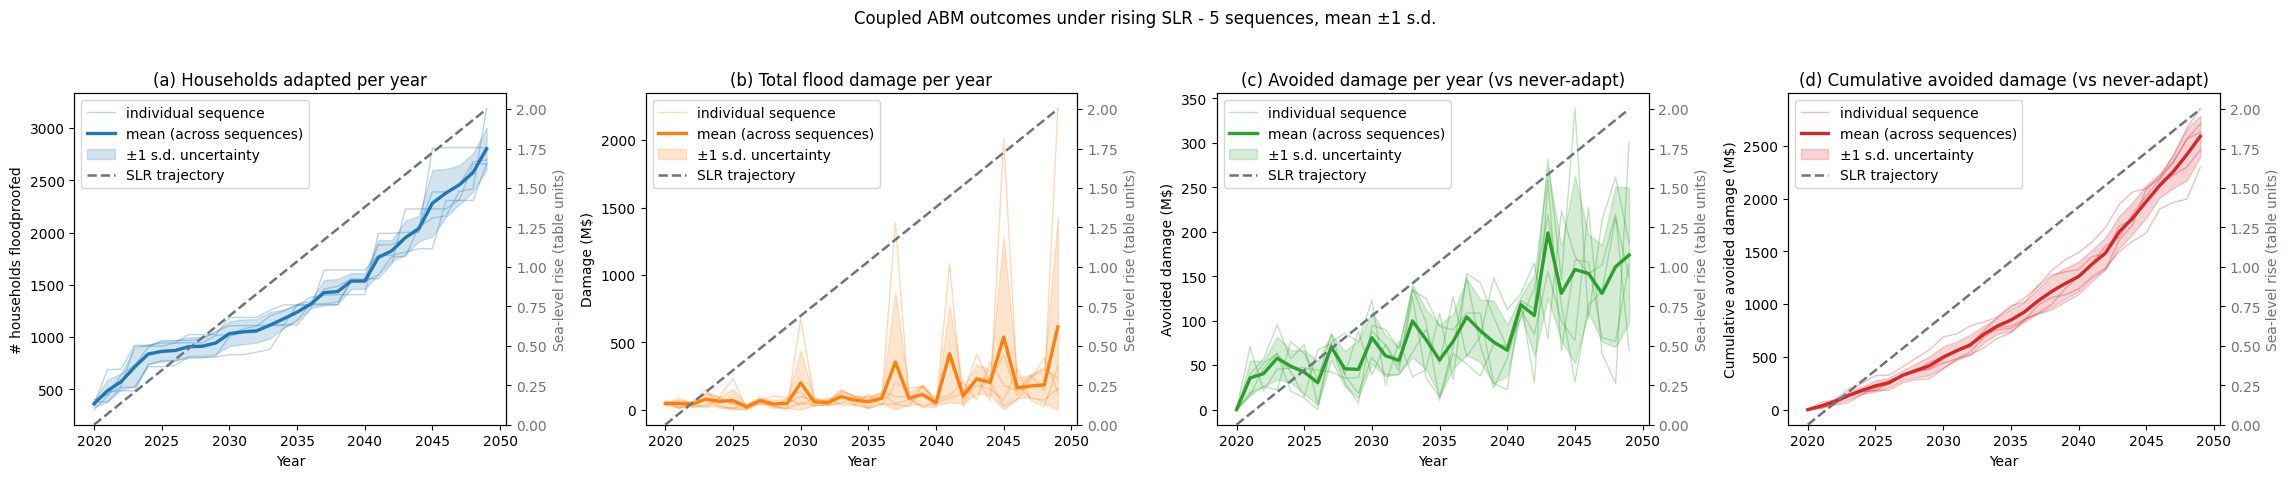

In [8]:
plot_results(years, slr_values, n_adapted, dmg_year, avoided_year, NO_SEQ)

### 4.3 Legacy ABM vs DYNAMO ABM

Before the 2026-07 review, events came from a clipped Bernoulli draw (cap 4 per year), flood perception was binary, income was proportional to building value, and adaptation used a fixed rule: floodproof when this year's damage exceeds 30 % of the maximum potential damage. `CouplingConfig.legacy()` pins that bit-exactly; **R2** runs it.

R2 and R1 differ in the hazard draw **and** the decision rule at once, so they are not directly comparable. **R3** closes the gap: the DYNAMO rule (ported `SEURule`, ACS income) on the **same event draws as R2**; the cell asserts this bit-for-bit. Read:

- **R2 vs R3**: the rule effect, under identical floods.
- **R3 vs R1**: the hazard effect (legacy clip-and-cap vs corrected Poisson), under the same rule.

R3 inherits the legacy hazard's flaws deliberately. It is a control, not a recommended setting.

R3 decision rule : DynamoLiveRule (status: preferred)


[calcEU_do_nothing] Warning, 46603 negative NPVs encountered in floodadapt_abm (0.38%)[calcEU_do_nothing] Warning, 46603 negative NPVs encountered in floodadapt_abm (0.38%)
[calcEU_do_nothing] Warning, 46603 negative NPVs encountered in floodadapt_abm (0.38%)
[calcEU_do_nothing] Warning, 46603 negative NPVs encountered in floodadapt_abm (0.38%)



[calcEU_do_nothing] Warning, 46603 negative NPVs encountered in floodadapt_abm (0.38%)


[calcEU_adapt] Warning, 8816 negative NPVs encountered in floodadapt_abm (0.07%)[calcEU_adapt] Warning, 8816 negative NPVs encountered in floodadapt_abm (0.07%)

[calcEU_adapt] Warning, 8816 negative NPVs encountered in floodadapt_abm (0.07%)


[calcEU_adapt] Warning, 8816 negative NPVs encountered in floodadapt_abm (0.07%)


...

SHARED EVENTS OK : R2 and R3 see bit-identical flood histories



R2 - Legacy ABM:


,sequence,final adopted (#),final adopted (%),cum. damage (M$),cum. avoided (M$)
0,seq 0,1207.0,2.1,1810.9,702.3
1,seq 1,1034.0,1.8,1706.4,985.5
2,seq 2,1485.0,2.6,2089.5,1276.0
3,seq 3,556.0,1.0,1351.5,620.5
4,seq 4,1293.0,2.2,1629.4,599.9
5,MEAN,1115.0,1.9,1717.5,836.8
6,STD,315.0,0.5,240.4,259.2


R3 - DYNAMO ABM, legacy hazard (same events as R2):


,sequence,final adopted (#),final adopted (%),cum. damage (M$),cum. avoided (M$)
0,seq 0,2486.0,4.3,1253.5,1262.2
1,seq 1,2397.0,4.1,1320.0,1383.4
2,seq 2,2425.0,4.2,1830.8,1537.0
3,seq 3,2320.0,4.0,840.7,1138.2
4,seq 4,2492.0,4.3,1010.0,1219.3
5,MEAN,2424.0,4.2,1251.0,1308.0
6,STD,63.3,0.1,336.9,139.3


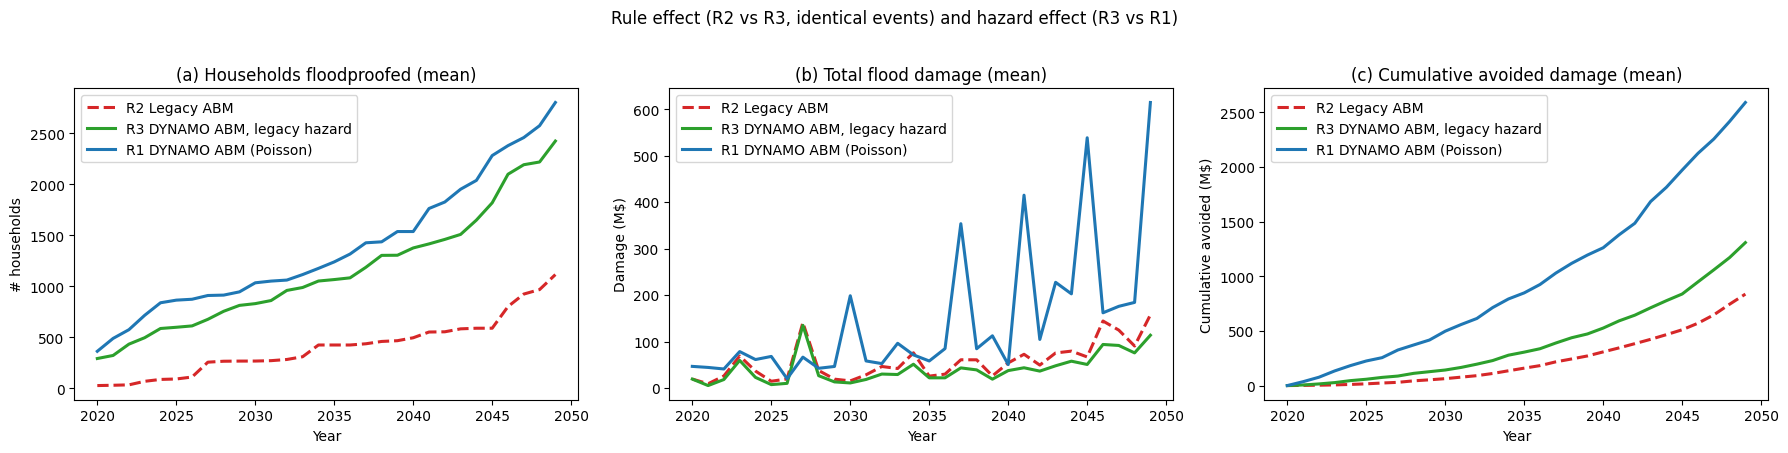

Rule effect (identical legacy event draws):
  R2 Legacy ABM               : final adopted  1.9% | cum. damage    1,718 M$ | cum. avoided     837 M$
  R3 DYNAMO ABM, legacy hazard: final adopted  4.2% | cum. damage    1,251 M$ | cum. avoided   1,308 M$
Hazard effect (same rule, legacy vs Poisson draw):
  R1 DYNAMO ABM               : final adopted  4.8% | cum. damage    4,361 M$ | cum. avoided   2,590 M$


In [9]:
# --- R2: Legacy ABM (legacy hazard + ThresholdRule 0.3 + legacy income) ------
legacy_config = CouplingConfig.legacy(random_seed=SEED)
legacy_engine = SimulationEngine(
    ds=ds,
    config=legacy_config,
    decision_rule=ThresholdRule(legacy_config.decision, damage_threshold=0.3),
)
legacy_res = legacy_engine.run(slr_values, no_seq=NO_SEQ, seed=SEED, n_jobs=-1)
legacy_engine._data.clear_interp_cache()   # memory hygiene (see Section 4.1)

# --- R2's never-adapt baseline (same legacy event stream) --------------------
legacy_base_config = CouplingConfig(
    decision=replace(legacy_config.decision, lifespan_dryproof=None),
    random_seed=SEED,
)
legacy_base_engine = SimulationEngine(
    ds=ds,
    config=legacy_base_config,
    decision_rule=ThresholdRule(legacy_base_config.decision, damage_threshold=1.01),
)
legacy_base = legacy_base_engine.run(slr_values, no_seq=NO_SEQ, seed=SEED, n_jobs=-1)
legacy_base_engine._data.clear_interp_cache()

# --- R3: DYNAMO ABM on the legacy hazard (same event draws as R2) ------------
matched_config = CouplingConfig(
    decision=replace(
        config.decision,
        event_draw_mode="bernoulli_clip",   # legacy draw
        max_events_per_year=4,              # legacy cap
        cap_policy="random",                # legacy discard
        nuisance_freq_threshold=None,       # legacy: no nuisance filter
    ),
    random_seed=SEED,
)
# Preferred rule (native DYNAMO-M when installed; parity-gated port else).
# Parallel-safe: each n_jobs worker clones the rule and gets its own
# native module. The native kernels hold the GIL, so this parallel run is
# correct but effectively serial; we accept that for native fidelity.
matched_rule = preferred_decision_rule(matched_config.decision)
print(f"R3 decision rule : {type(matched_rule).__name__} "
      f"(status: {matched_rule.STATUS})")
matched_engine = SimulationEngine(
    ds=ds,
    config=matched_config,
    decision_rule=matched_rule,
    income_percentile_per_agent=income_percentiles,
)
matched_res = matched_engine.run(slr_values, no_seq=NO_SEQ, seed=SEED, n_jobs=-1)
matched_engine._data.clear_interp_cache()

# Verify the shared-events premise: a never-adapt run under R3's hazard settings
# must reproduce R2's baseline damages bit-for-bit (damages depend only on events).
matched_base_engine = SimulationEngine(
    ds=ds,
    config=CouplingConfig(
        decision=replace(matched_config.decision, lifespan_dryproof=None),
        random_seed=SEED,
    ),
    decision_rule=ThresholdRule(matched_config.decision, damage_threshold=1.01),
    income_percentile_per_agent=income_percentiles,
)
matched_base = matched_base_engine.run(slr_values, no_seq=NO_SEQ, seed=SEED, n_jobs=-1)
matched_base_engine._data.clear_interp_cache()
assert np.array_equal(matched_base["damage_history"], legacy_base["damage_history"]), \
    "R2 and R3 do not share the same event draws"
print("SHARED EVENTS OK : R2 and R3 see bit-identical flood histories")

legacy_damage    = legacy_res["damage_history"].astype(np.float64)
legacy_adoption  = legacy_res["adoption_fraction"]
legacy_n_adapted = legacy_res["adapted_history"].sum(axis=1)
legacy_base_dmg  = legacy_base["damage_history"].astype(np.float64)

matched_damage    = matched_res["damage_history"].astype(np.float64)
matched_adoption  = matched_res["adoption_fraction"]
matched_n_adapted = matched_res["adapted_history"].sum(axis=1)

# Same format as Section 4.1; baseline = the legacy never-adapt run for both.
legacy_summary, legacy_dmg_year, legacy_avoided_year = create_summary_table(
    legacy_n_adapted, legacy_adoption, legacy_damage, legacy_base_dmg, NO_SEQ)
matched_summary, matched_dmg_year, matched_avoided_year = create_summary_table(
    matched_n_adapted, matched_adoption, matched_damage, legacy_base_dmg, NO_SEQ)
print("\nR2 - Legacy ABM:")
display(legacy_summary)
print("R3 - DYNAMO ABM, legacy hazard (same events as R2):")
display(matched_summary)

# Overlay: rule effect (R2 vs R3, identical events) + hazard effect (R3 vs R1).
fig, axes = plt.subplots(1, 3, figsize=(18, 4.4))
runs = [
    ("R2 Legacy ABM",                legacy_n_adapted,  legacy_dmg_year,  legacy_avoided_year,  "C3", "--"),
    ("R3 DYNAMO ABM, legacy hazard", matched_n_adapted, matched_dmg_year, matched_avoided_year, "C2", "-"),
    ("R1 DYNAMO ABM (Poisson)",      n_adapted,         dmg_year,         avoided_year,         "C0", "-"),
]
for label, n_ad, dmg, avoided, c, ls in runs:
    axes[0].plot(years, n_ad.mean(0), color=c, ls=ls, lw=2.2, label=label)
    axes[1].plot(years, dmg.mean(0), color=c, ls=ls, lw=2.2, label=label)
    axes[2].plot(years, np.cumsum(avoided, axis=1).mean(0), color=c, ls=ls, lw=2.2, label=label)
axes[0].set_title("(a) Households floodproofed (mean)")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("# households"); axes[0].legend()
axes[1].set_title("(b) Total flood damage (mean)")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("Damage (M$)"); axes[1].legend()
axes[2].set_title("(c) Cumulative avoided damage (mean)")
axes[2].set_xlabel("Year"); axes[2].set_ylabel("Cumulative avoided (M$)"); axes[2].legend()
fig.suptitle("Rule effect (R2 vs R3, identical events) and hazard effect (R3 vs R1)", y=1.02)
fig.tight_layout(); plt.show()

print("Rule effect (identical legacy event draws):")
print(f"  R2 Legacy ABM               : final adopted {legacy_adoption[:, -1].mean():5.1%}"
      f" | cum. damage {legacy_dmg_year.sum(1).mean():>8,.0f} M$"
      f" | cum. avoided {legacy_avoided_year.sum(1).mean():>7,.0f} M$")
print(f"  R3 DYNAMO ABM, legacy hazard: final adopted {matched_adoption[:, -1].mean():5.1%}"
      f" | cum. damage {matched_dmg_year.sum(1).mean():>8,.0f} M$"
      f" | cum. avoided {matched_avoided_year.sum(1).mean():>7,.0f} M$")
print("Hazard effect (same rule, legacy vs Poisson draw):")
print(f"  R1 DYNAMO ABM               : final adopted {adoption[:, -1].mean():5.1%}"
      f" | cum. damage {dmg_year.sum(1).mean():>8,.0f} M$"
      f" | cum. avoided {avoided_year.sum(1).mean():>7,.0f} M$")

# Memory hygiene: keep only the aggregates used above.
del legacy_res, legacy_base, matched_res, matched_base
del legacy_damage, matched_damage, legacy_base_dmg
del legacy_engine, legacy_base_engine, matched_engine, matched_base_engine
gc.collect();

## 5. Insurance experiment: from adapt-or-not to a three-way choice

Two settings:

- **Adaptation only: R1** (Section 3, `include_insurance=False`). Each year a household floodproofs or does nothing.
- **Adaptation plus insurance: R4 and R5** (`include_insurance=True`). The same yearly decision becomes three-way: do nothing, floodproof, or insure. The insurance branch uses the ported native `calcEU_insure`.

**Decision rules, explicit.** R1 uses the native `DynamoLiveRule` when a DYNAMO-M checkout is present, else the ported `SEURule` (parity-verified, identical decisions). R4 and R5 use the **ported `SEURule` with the three-way `decide()`**, on the same hazard stream as R1. The legacy run R2 uses `ThresholdRule(0.3)`. Full inventory: Section 2.7.

Rules of the game:

- insured households still bear a **10 % deductible**: the share of the damage the insured household still pays itself (native default);
- the **6 % expenditure cap** also applies to the premium. An unaffordable premium sets `EU_insure = -inf`, so the household never insures;
- insurance is **annual** (re-decided every year) and never overrides physical floodproofing.

`damage_history` stays gross (before any payout); the run additionally reports `insured_history`, `out_of_pocket_history`, `premium_history` and `premium_paid_history`.

### 5.1 What the pricing modes mean, and where they come from

`insurance_pricing` selects the insurer's rating rule:

| Mode | Premium charged | Meaning | Origin |
|---|---|---|---|
| `"community"` (default) | the **mean** expected annual damage of the pool, one flat rate for everybody | Low-risk households cross-subsidise high-risk ones. Over a skewed pool the flat rate sits far above the median household's own risk | native DYNAMO-M `InsurerAgent.derive_premium` |
| `"risk_based"` | each household's **own** expected payout, `(1 - deductible) x EAD_i` | The actuarially fair price: it exactly covers the insurer's expected payments for that household. No cross-subsidy | beyond native |

Jargon, defined: **EAD** (expected annual damage) is the damage a household expects in an average year, the sum of each event's damage times its yearly rate. **Actuarially fair** means priced exactly at expected cost, with no margin.

**Provenance.** *Community rating* is native DYNAMO-M's insurer. It mirrors real community-rated flood schemes, such as the US National Flood Insurance Program (NFIP) before its 2021 reform. *Risk-based pricing* is the standard actuarial benchmark (premium = expected loss) and the direction real programs are moving (NFIP "Risk Rating 2.0"). It is added **beyond native** for two reasons: (1) as a diagnostic, to test whether the flat community rate is what suppresses uptake (Section 5.2 shows it is not; the expenditure cap binds under either rule); (2) to make the premium side policy-relevant: the pricing mode together with `insurance_loading` (insurer margin, `1.0` = at cost) and `insurance_subsidy` (public share of the premium) spans the premium designs a public insurer or regulator could set.

The cell below runs R4 and R5 and compares against R1. Watch two things: how much insurance is taken up, and whether offering insurance changes floodproofing (a "crowding out" effect).

R4 decision rule : DynamoLiveRule (status: preferred; three-way decide)


[calcEU_do_nothing] Warning, 46583 negative NPVs encountered in floodadapt_abm (0.4%)
[calcEU_do_nothing] Warning, 46583 negative NPVs encountered in floodadapt_abm (0.4%)
[calcEU_do_nothing] Warning, 46583 negative NPVs encountered in floodadapt_abm (0.4%)
[calcEU_do_nothing] Warning, 46583 negative NPVs encountered in floodadapt_abm (0.4%)


[calcEU_do_nothing] Warning, 46583 negative NPVs encountered in floodadapt_abm (0.4%)


[calcEU_adapt] Warning, 8816 negative NPVs encountered in floodadapt_abm (0.08%)
[calcEU_adapt] Warning, 8816 negative NPVs encountered in floodadapt_abm (0.08%)
[calcEU_adapt] Warning, 8816 negative NPVs encountered in floodadapt_abm (0.08%)
[calcEU_adapt] Warning, 8816 negative NPVs encountered in floodadapt_abm (0.08%)
[calcEU_adapt] Warning, 8816 negative NPVs encountered in floodadapt_abm (0.08%)


[calcEU_insure] Warning, 50 negative NPVs encountered in floodadapt_abm (0.0%)
[calcEU_insure] Warning, 50 negative NPVs encountered in floodadapt_abm (0.0%)
[calcEU_insure] Warning, 50 negative NPVs encountered in floodadapt_abm (0.0%)
[calcEU_insure] Warning, 50 negative NPVs encountered in floodadapt_abm (0.0%)
[calcEU_insure] Warning, 50 negative NPVs encountered in floodadapt_abm (0.0%)


...

[calcEU_adapt] Warning, 127550 negative NPVs encountered in floodadapt_abm (1.11%)
[calcEU_adapt] Warning, 127519 negative NPVs encountered in floodadapt_abm (1.11%)
[calcEU_adapt] Warning, 127565 negative NPVs encountered in floodadapt_abm (1.11%)


[calcEU_insure] Warning, 49297 negative NPVs encountered in floodadapt_abm (0.43%)
[calcEU_insure] Warning, 49297 negative NPVs encountered in floodadapt_abm (0.43%)


[calcEU_insure] Warning, 49297 negative NPVs encountered in floodadapt_abm (0.43%)


[calcEU_insure] Warning, 49297 negative NPVs encountered in floodadapt_abm (0.43%)
[calcEU_insure] Warning, 49297 negative NPVs encountered in floodadapt_abm (0.43%)


R5 decision rule : SEURule (status: reference; three-way decide)


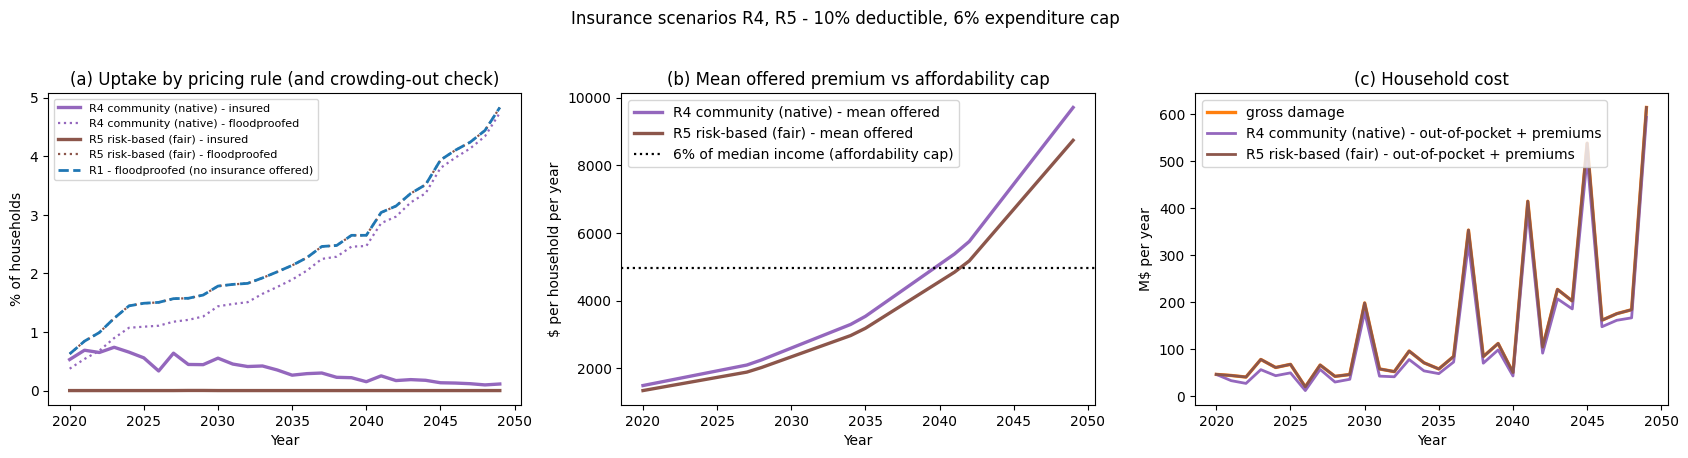

R1 (adaptation only)         | final floodproofed  4.83%
R4 community (native)    | peak uptake  0.74%  final  0.11%  | final floodproofed  4.74%  | mean premium y1 $1,487 -> y30 $9,710
R5 risk-based (fair)     | peak uptake  0.00%  final  0.00%  | final floodproofed  4.83%  | mean premium y1 $1,338 -> y30 $8,739


In [10]:
# R4, R5: insurance scenarios, community vs risk-based pricing,
# compared against R1 (the Section-3 run, no insurance).
# Decision rule per scenario via preferred_decision_rule: R4 (community
# pricing) runs the native DynamoLiveRule; R5 (risk-based) runs the ported
# SEURule, because native calcEU_insure prices one flat premium and cannot
# price per household (see Section 2.8).
# Uses engine.run(n_jobs=-1); DynamoLiveRule.clone() is worker-safe.
def run_insurance(label, pricing, subsidy=0.0, loading=1.0):
    ins_cfg = CouplingConfig(
        decision=replace(
            config.decision,
            include_insurance=True,
            insurance_pricing=pricing,
            insurance_subsidy=subsidy,
            insurance_loading=loading,
        ),
        random_seed=SEED,
    )
    rule = preferred_decision_rule(ins_cfg.decision)
    print(f"{label} decision rule : {type(rule).__name__} "
          f"(status: {rule.STATUS}; three-way decide)")
    eng = SimulationEngine(ds=ds, config=ins_cfg,
                           decision_rule=rule,
                           income_percentile_per_agent=income_percentiles)
    res = eng.run(slr_values, no_seq=NO_SEQ, seed=SEED, n_jobs=-1)
    eng._data.clear_interp_cache()   # memory hygiene (see Section 4.1)
    return res

scenarios = {
    "R4 community (native)":  run_insurance("R4", "community"),
    "R5 risk-based (fair)":   run_insurance("R5", "risk_based"),
}
colors = {"R4 community (native)": "C4", "R5 risk-based (fair)": "C5"}
cap_budget = np.median(engine._data.income) * config.decision.expenditure_cap

fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))

ax = axes[0]
for label, res in scenarios.items():
    ax.plot(years, 100 * res["insured_fraction"].mean(0), lw=2.4,
            color=colors[label], label=f"{label} - insured")
    ax.plot(years, 100 * res["adoption_fraction"].mean(0), lw=1.6, ls=":",
            color=colors[label], label=f"{label} - floodproofed")
ax.plot(years, 100 * results["adoption_fraction"].mean(0), lw=2.0, color="C0",
        ls="--", label="R1 - floodproofed (no insurance offered)")
ax.set_title("(a) Uptake by pricing rule (and crowding-out check)")
ax.set_xlabel("Year"); ax.set_ylabel("% of households"); ax.legend(fontsize=8)

ax = axes[1]
for label, res in scenarios.items():
    ax.plot(years, res["premium_history"].mean(0), lw=2.4, color=colors[label],
            label=f"{label} - mean offered")
ax.axhline(cap_budget, color="k", ls=":", lw=1.6,
           label="6% of median income (affordability cap)")
ax.set_title("(b) Mean offered premium vs affordability cap")
ax.set_xlabel("Year"); ax.set_ylabel("$ per household per year"); ax.legend()

ax = axes[2]
gross = results["damage_history"].astype(np.float64).sum(axis=1).mean(0) / 1e6
ax.plot(years, gross, color="C1", lw=2.4, label="gross damage")
for label, res in scenarios.items():
    total = (res["out_of_pocket_history"].astype(np.float64)
             + res["premium_paid_history"].astype(np.float64)).sum(axis=1).mean(0) / 1e6
    ax.plot(years, total, lw=2.0, color=colors[label],
            label=f"{label} - out-of-pocket + premiums")
ax.set_title("(c) Household cost")
ax.set_xlabel("Year"); ax.set_ylabel("M$ per year"); ax.legend()

fig.suptitle("Insurance scenarios R4, R5 - 10% deductible, 6% expenditure cap", y=1.03)
fig.tight_layout(); plt.show()

print("R1 (adaptation only)         | final floodproofed "
      f"{100 * results['adoption_fraction'].mean(0)[-1]:5.2f}%")
for label, res in scenarios.items():
    ins = res["insured_fraction"].mean(0)
    prem = res["premium_history"].mean(0)
    fp = res["adoption_fraction"].mean(0)
    print(f"{label:24s} | peak uptake {100*ins.max():5.2f}%  final {100*ins[-1]:5.2f}%"
          f"  | final floodproofed {100*fp[-1]:5.2f}%"
          f"  | mean premium y1 ${prem[0]:,.0f} -> y{N_YEARS} ${prem[-1]:,.0f}")

# Memory hygiene: the scenario payloads are no longer needed after the prints.
del scenarios, res
gc.collect();

### 5.2 Why is uptake so low? The affordability pincer

Both rating rules produce near-zero uptake, but for **opposite reasons**. The cell below diagnoses it at the final sea level by splitting the population by risk.

The risk pool is extremely **skewed**. Mean EAD is about \$9,700 per household, but the median is only \$136 and the 99th percentile is above \$187,000. About 38 % of households have an EAD of \$0, meaning there is nothing to insure. Six percent of the median income is about \$5,000.

- Under **community rating**, the flat premium is the *mean* EAD, roughly \$8,700 by the final year. That is far above what a median-risk household would ever pay for its own tiny risk, and above the 6 % budget of about three quarters of the population. Only the households for whom the flat rate is a bargain, the **cross-subsidised high-risk tail**, have a reason to buy. That is where the small uptake comes from, and it shrinks as the rising flat rate outgrows more and more budgets.
- Under **risk-based rating**, the premium *is* each household's own risk. The median premium collapses to about \$120 and most households (83 %) can afford cover. But affordability and need are inversely sorted. The low-risk majority can pay easily and has nothing worth insuring. Roughly 95 % of the high-risk decile is priced above its 6 % budget and struck out by the affordability constraint (`EU_insure = -inf`). For the small affordable remainder, the expected-utility comparison still favours floodproofing or doing nothing over an annual policy, so uptake stays at zero.

That is the pincer: **the households who would buy cover cannot afford it, and the households who can afford it do not need it.**

The income workflow of Section 2.6 matters here. With real ACS county incomes and the value-proxy pairing of income and risk, more households clear the affordability bar than under a flat \$70k assumption. The pincer's shape is unchanged, but its sharpness depends on the income model. This is exactly why the income inputs are recorded as explicit, replaceable tiers.

,pricing,median premium ($/yr),affordable - all households,affordable - top-10% risk
0,community (flat),"8,739",27.5%,27.9%
1,risk-based,122,83.0%,4.5%


EAD skew         : mean $9,710 | median $136 | p99 $187,331
households with EAD = $0 (nothing to insure): 37.6%
6% budget        : median $4,961


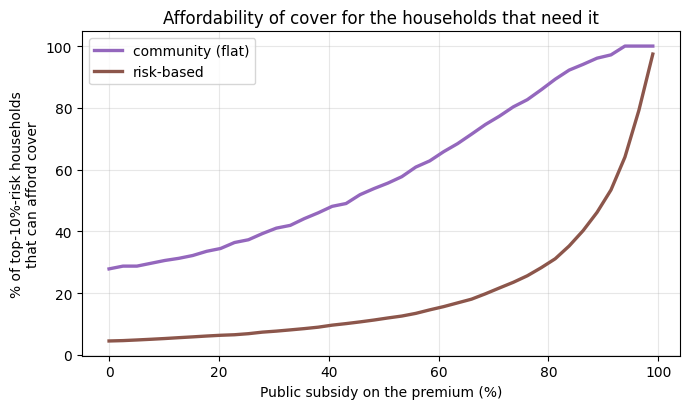

In [11]:
# Diagnostic at the final sea level: who can afford cover, and who needs it?
diag = SimulationEngine(ds=ds, config=config,
                        income_percentile_per_agent=income_percentiles)
diag.prepare_damages(float(slr_values[-1]))
ead = diag._data.compute_expected_annual_damages(False)          # per household
budget = diag._data.income * config.decision.expenditure_cap     # 6% of income
deduct = config.decision.insurance_deductible

premium_flat = np.full_like(ead, (1.0 - deduct) * ead.mean())    # community rating
premium_risk = (1.0 - deduct) * ead                              # risk-based rating

high_risk = ead >= np.percentile(ead, 90)        # the top-decile risk tail
rows = []
for label, prem in (("community (flat)", premium_flat), ("risk-based", premium_risk)):
    rows.append({
        "pricing": label,
        "median premium ($/yr)": f"{np.median(prem):,.0f}",
        "affordable - all households": f"{100 * np.mean(budget > prem):.1f}%",
        "affordable - top-10% risk":   f"{100 * np.mean((budget > prem)[high_risk]):.1f}%",
    })
display(pd.DataFrame(rows))

print(f"EAD skew         : mean ${ead.mean():,.0f} | median ${np.median(ead):,.0f} "
      f"| p99 ${np.percentile(ead, 99):,.0f}")
print(f"households with EAD = $0 (nothing to insure): {100 * np.mean(ead <= 0):.1f}%")
print(f"6% budget        : median ${np.median(budget):,.0f}")

# How deep would a subsidy have to be to make cover reachable for the tail?
fig, ax = plt.subplots(figsize=(7, 4.2))
subs = np.linspace(0, 0.99, 40)
for label, prem, c in (("community (flat)", premium_flat, "C4"),
                       ("risk-based", premium_risk, "C5")):
    ax.plot(100 * subs,
            [100 * np.mean((budget > (1 - s) * prem)[high_risk]) for s in subs],
            lw=2.4, color=c, label=label)
ax.set_xlabel("Public subsidy on the premium (%)")
ax.set_ylabel("% of top-10%-risk households\nthat can afford cover")
ax.set_title("Affordability of cover for the households that need it")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

### 5.3 Reading of the insurance results

1. **Voluntary uptake is governed by the expenditure cap, not by the availability of insurance.** In this SEU formulation a household insures only if the premium fits inside 6 % of its income *and* the perceived risk makes cover worth more than doing nothing. For the Charleston pool those two conditions are almost disjoint.
2. **Actuarial fairness alone does not create a market.** Risk-based pricing is the textbook fix for a skewed pool, and it does make cover affordable for the low-risk majority. But it prices most of the high-risk tail out entirely. Community rating is the only rule here that puts *any* households under cover, and it does so purely by cross-subsidy.
3. **Rising sea level erodes the market.** The mean EAD (and hence the flat premium) grows several-fold over the horizon, crossing the affordability cap of more and more households. Uptake therefore decays exactly as the risk becomes most severe.
4. **No meaningful crowding out.** Comparing R4 and R5 against R1, final floodproofing is essentially unchanged (4.7 to 4.8 % in all runs). At these premium levels insurance does not displace physical adaptation.
5. **The policy lever is the premium-to-income ratio, not the rating rule.** The subsidy curve above shows what fraction of the at-risk tail could be covered at each subsidy level; only deep subsidies (or a mandate, public reinsurance, or means-tested vouchers) put the tail under cover. This mirrors the empirical record for voluntary flood insurance.

> **Caveat on the ported insurer.** Both rules inherit native DYNAMO-M's simplifications: a single flat community rate with no risk classes, no experience rating, no claims/solvency dynamics, and a premium that is re-derived every year from the current-SLR EAD. Native also charges the full mean EAD while covering only 90 % of losses (an implicit ~11 % loading), which we keep for `"community"` and correct for `"risk_based"`. A richer insurer (risk bands, multi-year contracts, capital constraints) is the natural next extension, and would plug into the same `insurance_pricing` seam.

## Appendix A: parity spot-check (verification paths)

The bit-parity contract (`run_mesa_native_full` ≡ `run_mesa_native` ≡ `engine.run(n_jobs=...)`) is enforced continuously by the test suite (`pytest tests/ -q`) and the harnesses in `verification/`. The single cell below is a spot-check that the two verification paths reproduce the Section-3 run (R1) **bit-for-bit** on this very dataset and seed.

In [12]:
# Verification paths on the same engine/seeds as R1 (Section 3).
mirror   = run_mesa_native(engine, slr_values, no_seq=NO_SEQ, seed=SEED, track_eu=True)
parallel = engine.run(slr_values, no_seq=NO_SEQ, seed=SEED, n_jobs=-1)

# Bit-for-bit equality is the coupling's correctness contract.
assert np.array_equal(mirror["damage_history"],  results["damage_history"]),  "mirror != R1"
assert np.array_equal(mirror["adapted_history"], results["adapted_history"]), "mirror != R1"
assert np.array_equal(parallel["damage_history"],  results["damage_history"]),  "parallel != R1"
assert np.array_equal(parallel["adapted_history"], results["adapted_history"]), "parallel != R1"
print("PARITY OK: run_mesa_native == engine.run(n_jobs=-1) == run_mesa_native_full (bit-for-bit)")

# Memory hygiene: drop the verification payloads once the asserts have passed.
del mirror, parallel
gc.collect();

[calcEU_do_nothing] Warning, 46583 negative NPVs encountered in floodadapt_abm (0.4%)


[calcEU_adapt] Warning, 8816 negative NPVs encountered in floodadapt_abm (0.08%)


[calcEU_do_nothing] Warning, 48666 negative NPVs encountered in floodadapt_abm (0.42%)


[calcEU_adapt] Warning, 9397 negative NPVs encountered in floodadapt_abm (0.08%)


[calcEU_do_nothing] Warning, 51056 negative NPVs encountered in floodadapt_abm (0.44%)


...

[calcEU_adapt] Warning, 121135 negative NPVs encountered in floodadapt_abm (1.05%)


[calcEU_adapt] Warning, 121100 negative NPVs encountered in floodadapt_abm (1.05%)
[calcEU_adapt] Warning, 121116 negative NPVs encountered in floodadapt_abm (1.05%)
[calcEU_adapt] Warning, 121146 negative NPVs encountered in floodadapt_abm (1.05%)
[calcEU_adapt] Warning, 121109 negative NPVs encountered in floodadapt_abm (1.05%)


[calcEU_do_nothing] Warning, 255083 negative NPVs encountered in floodadapt_abm (2.21%)
[calcEU_do_nothing] Warning, 255083 negative NPVs encountered in floodadapt_abm (2.21%)
[calcEU_do_nothing] Warning, 255083 negative NPVs encountered in floodadapt_abm (2.21%)
[calcEU_do_nothing] Warning, 255083 negative NPVs encountered in floodadapt_abm (2.21%)
[calcEU_do_nothing] Warning, 255083 negative NPVs encountered in floodadapt_abm (2.21%)


[calcEU_adapt] Warning, 127550 negative NPVs encountered in floodadapt_abm (1.11%)
[calcEU_adapt] Warning, 127519 negative NPVs encountered in floodadapt_abm (1.11%)
[calcEU_adapt] Warning, 127561 negative NPVs encountered in floodadapt_abm (1.11%)
[calcEU_adapt] Warning, 127540 negative NPVs encountered in floodadapt_abm (1.11%)
[calcEU_adapt] Warning, 127565 negative NPVs encountered in floodadapt_abm (1.11%)


PARITY OK: run_mesa_native == engine.run(n_jobs=-1) == run_mesa_native_full (bit-for-bit)
